In [66]:
# needed packages
import os

import random

from pathlib import Path

# data manipulation
import numpy as np
np.random.seed(0)
import pandas as pd

# data viz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# for image
import cv2
import PIL as pil

# for model
import tensorflow as tf
tf.random.set_seed(0) #

from tensorflow import keras
from keras import layers,models

# To reduce the warnings
import warnings
warnings.filterwarnings('ignore')

In [67]:
# the path of the file in the local system

data_dir=Path("D:\plant_disease_colored")

In [68]:
data_dir

WindowsPath('D:/plant_disease_colored')

In [69]:
# total number of images present in the dataset

print(f"total images in the dataset is {len(list(data_dir.rglob('*/*.jpg')))}")

total images in the dataset is 18159


In [70]:
# number of classes in the dataset

print("no: of files in dataset: ",len(os.listdir(data_dir)))

no: of files in dataset:  10


## Sampling and Visualizing the data in the dataset

In [71]:
# the total classes in the dataset

classes=list(os.listdir(data_dir))

In [72]:
classes[:3]

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy']

In [75]:
# for visualizing some images and look its dimensions

tomato=list(data_dir.rglob('Tomato___Early_blight/*.[jJ][pP][gG]'))

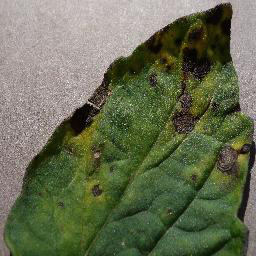

In [76]:
pil.Image.open(str(tomato[0]))

In [79]:
img=cv2.imread(str(tomato[0]))

In [80]:
print(img)

[[[171 172 182]
  [170 171 181]
  [173 174 184]
  ...
  [170 170 176]
  [165 165 171]
  [178 178 184]]

 [[170 171 181]
  [170 171 181]
  [172 173 183]
  ...
  [169 169 175]
  [162 162 168]
  [174 174 180]]

 [[171 172 182]
  [173 174 184]
  [175 176 186]
  ...
  [177 177 183]
  [168 168 174]
  [181 181 187]]

 ...

 [[ 92 104 114]
  [ 98 110 120]
  [116 125 138]
  ...
  [105 105 117]
  [109 105 116]
  [112 106 117]]

 [[ 91 106 115]
  [ 93 108 117]
  [109 121 133]
  ...
  [106 106 118]
  [115 109 120]
  [116 108 119]]

 [[ 92 109 118]
  [ 90 107 116]
  [106 117 131]
  ...
  [107 107 119]
  [119 113 124]
  [120 112 123]]]


In [81]:
print(f'the dimension of the image is {img.shape[:2]}')

the dimension of the image is (256, 256)


In [82]:
# in the empty dict storing all the contents of the classes

plant_dict={}
for class_name in classes:
    plant_dict[class_name]=list(data_dir.rglob(f'{class_name}/*.[jJ][pP][gG]'))# [jJ][pP][gG] matches .jpg, .JPG, .Jpg, etc(used for case sensitivity)

In [83]:
# classifications in the dataset

plant_label_dict={}
for i,classes in enumerate(classes):
  plant_label_dict[classes]=i

In [84]:
plant_dict.keys()

dict_keys(['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus'])

In [85]:
plant_label_dict

{'Tomato___Bacterial_spot': 0,
 'Tomato___Early_blight': 1,
 'Tomato___healthy': 2,
 'Tomato___Late_blight': 3,
 'Tomato___Leaf_Mold': 4,
 'Tomato___Septoria_leaf_spot': 5,
 'Tomato___Spider_mites Two-spotted_spider_mite': 6,
 'Tomato___Target_Spot': 7,
 'Tomato___Tomato_mosaic_virus': 8,
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 9}

In [86]:
# number images in each classes in the dataset to train
# no of classes: 10

for classes, images in plant_dict.items():
    print(f"The {classes} has {len(images)} images.\n")

The Tomato___Bacterial_spot has 2127 images.

The Tomato___Early_blight has 1000 images.

The Tomato___healthy has 1591 images.

The Tomato___Late_blight has 1908 images.

The Tomato___Leaf_Mold has 952 images.

The Tomato___Septoria_leaf_spot has 1771 images.

The Tomato___Spider_mites Two-spotted_spider_mite has 1676 images.

The Tomato___Target_Spot has 1404 images.

The Tomato___Tomato_mosaic_virus has 373 images.

The Tomato___Tomato_Yellow_Leaf_Curl_Virus has 5357 images.



In [90]:
# image paramaters

image_size=(224,224)
batch_size=32

In [91]:
# pipelines

# data generator
data_gen=keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
print("training set:")
# training generator
train_gen=data_gen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

print("validation set:")
# validation generator
valid_gen=  data_gen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

# data augmentation
data_augmentation=keras.Sequential([
    layers.RandomFlip("horizontal",),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

training set:
Found 14532 images belonging to 10 classes.
validation set:
Found 3628 images belonging to 10 classes.


In [92]:
# model building

model=keras.Sequential([
  layers.Input(shape=(224, 224, 3)),
  data_augmentation,

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.25),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.25),

  layers.Flatten(),

  layers.Dense(256, activation='relu',kernel_initializer='he_normal'),
  layers.Dropout(0.5),

  layers.Dense(train_gen.num_classes, activation='softmax',kernel_initializer='glorot_uniform')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [93]:
# fitting the model

cnn=model.fit(train_gen,
                  epochs=5,
                  validation_data=valid_gen
               )

Epoch 1/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 526s 1s/step - accuracy: 0.5325 - loss: 1.6842 - val_accuracy: 0.7098 - val_loss: 0.8464
Epoch 2/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 614s 1s/step - accuracy: 0.7094 - loss: 0.8487 - val_accuracy: 0.7696 - val_loss: 0.6578
Epoch 3/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.7672 - loss: 0.6765 - val_accuracy: 0.7778 - val_loss: 0.6775
Epoch 4/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.7963 - loss: 0.5940 - val_accuracy: 0.7412 - val_loss: 0.8238
Epoch 5/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.8188 - loss: 0.5245 - val_accuracy: 0.8275 - val_loss: 0.5397


In [95]:
cnn.history

{'accuracy': [0.5324800610542297,
  0.709399938583374,
  0.7672033905982971,
  0.796311616897583,
  0.818813681602478],
 'loss': [1.6841684579849243,
  0.8487460613250732,
  0.676529049873352,
  0.5939964056015015,
  0.5244654417037964],
 'val_accuracy': [0.7097574472427368,
  0.769569993019104,
  0.7778390049934387,
  0.7411797046661377,
  0.8274531364440918],
 'val_loss': [0.8463960289955139,
  0.6578291654586792,
  0.6775307655334473,
  0.8238435983657837,
  0.5396994352340698]}

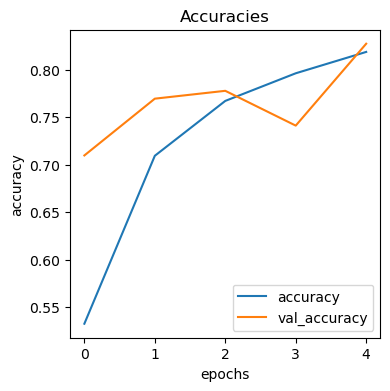

In [114]:
# visualizing the increase in accuracy of the model

plt.figure(figsize=(4,4))
plt.title('Accuracies')
plt.plot(cnn.history['accuracy'])
plt.plot(cnn.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['accuracy','val_accuracy'],loc='lower right')
plt.show()

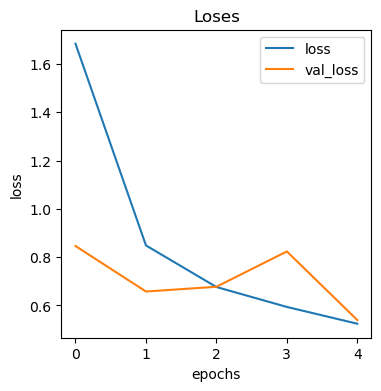

In [116]:
# visualizing depriciating loss in the model

plt.figure(figsize=(4,4))
plt.title('Loses')
plt.plot(cnn.history['loss'])
plt.plot(cnn.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['loss','val_loss'],loc='upper right')
plt.show()

## Manually predicting with examples

In [118]:
# the classes in the dataset from train_gen

class_={j: i for i, j in train_gen.class_indices.items() }

In [119]:
class_

{0: 'Tomato___Bacterial_spot',
 1: 'Tomato___Early_blight',
 2: 'Tomato___Late_blight',
 3: 'Tomato___Leaf_Mold',
 4: 'Tomato___Septoria_leaf_spot',
 5: 'Tomato___Spider_mites Two-spotted_spider_mite',
 6: 'Tomato___Target_Spot',
 7: 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 8: 'Tomato___Tomato_mosaic_virus',
 9: 'Tomato___healthy'}

In [150]:
# function for predicting an image

def load_process_image(img_path,target_size=(224,224)):
    img=pil.Image.open(img_path)
    resized_img=img.resize(target_size)
    image_arr=np.array(resized_img)
    image_np_arr_=np.expand_dims(image_arr,axis=0)
    image_arr=image_np_arr_.astype('float32')/255.0
    return image_arr

def predictor(model,img_path,class_):
    processed_img=load_process_image(img_path)
    pred=model.predict(processed_img)
    index_of_pred=np.argmax(pred,axis=1)[0]
    actual_pred=class_[index_of_pred]
    return actual_pred

In [151]:
test_img_path=Path(r"D:\plant_disease_colored\Tomato___Leaf_Mold\1c03ffcb-9476-453c-96be-5bd1f629b2d1___Crnl_L.Mold 8853.JPG")
predictor(model,test_img_path,class_)

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


'Tomato___Septoria_leaf_spot'

In [152]:
# saving classes of the dataset as json file

json.dump(class_,open('class_indices.json','w'))

In [153]:
# saving model as keras file

model.save('plant_disease_diagnostics_cnn.keras')

In [154]:
# saving model as h5 file

model.save('plant_disease_diagnostics_CNN.h5')